# H2 — Random Forest: raw ATC similarity score vs. node2vec embeddings

## Purpose
Compares two ways of turning ATC-classification similarity into features for a DDI classifier, both trained and evaluated on the **exact same rows and train/test split**:

- **Model A (similarity score):** a Random Forest using only the raw `atc_similarity_score` scalar for each drug pair.
- **Model B (node2vec embeddings):** a Random Forest using node2vec embeddings of both drugs, combined into a pair-level feature vector.

**Task:** predict whether a drug pair is an *adverse* interaction (label = 1) or a *non-interacting* pair (label = 0). Same methodology as [`structural_sim_embedding_comparison.ipynb`](../h3_structural_similarity/structural_sim_embedding_comparison.ipynb) (H3), minus the raw-fingerprint third model -- ATC classification codes don't have an equivalent fixed-size raw numeric representation the way Morgan fingerprints do, so only the two comparable representations are tested here.

## Important: why this notebook loads a combined-graph embedding, not the per-population ones

`node2vec_embedding.ipynb` saves **three** embedding tables: `adverse_atc_node2vec.parquet` and `non_interacting_atc_node2vec.parquet` (one per population, for diagnosing each graph's topology in isolation) and `combined_atc_node2vec.parquet` (one shared model trained on the union of both populations). Model B here uses **only the combined one**, and it's worth being explicit about why:

The two per-population embedding tables come from **two separately-trained node2vec models**. Skip-gram embeddings have no canonical coordinate system: each training run's vector space is its own arbitrary rotation/scale, only meaningful relative to itself. If we built a classifier where every label=1 row's embeddings came from model_adverse and every label=0 row's embeddings came from model_non_interacting, the classifier could trivially separate the classes by detecting *which arbitrary vector space* a pair's embeddings came from -- **not** by learning genuine ATC-similarity signal. Worse, at prediction time for a genuinely new pair, there'd be no way to know *which* graph's embedding to use without already knowing the label you're trying to predict.

**The fix (already applied in `node2vec_embedding.ipynb` Section 7):** train **one** node2vec model on a **single combined graph** built from the union of both pair populations, with label-agnostic edge weights (the raw ATC similarity score). This notebook just loads that result rather than rebuilding it.

## Pipeline
1. Load & label both pair populations (adverse = 1, non_interacting = 0).
2. Load the canonical combined-graph node2vec embedding (built in `node2vec_embedding.ipynb`).
3. Sample pairs and build one shared train/test split used identically by both models.
4. Train Model A (raw similarity score) and Model B (node2vec embeddings).
5. Evaluate both with the same metrics, side by side.
6. Conclusions & recommendations.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

sns.set_theme(style="whitegrid")

H2_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity")
EMBEDDING_DIR = H2_DIR / "embeddings"
MODEL_OUTPUT_DIR = H2_DIR / "models" / "atc_rf_comparison"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Configuration

`MAX_PAIRS_PER_CLASS` caps how many rows are sampled per label before training -- both classes have far more pairs than needed for a Random Forest to converge, and using equal counts per class gives a balanced 50/50 training set. Set it to `None` to use every available row (slower).

In [2]:
# --- Data sources ---
ADVERSE_PATH = H2_DIR / "adverse_atc_sim.parquet"
NON_INTERACTING_PATH = H2_DIR / "non_interacting_atc_sim.parquet"

# --- Pair-embedding combination strategy ---
# "hadamard" -> elementwise product of the two drugs' embeddings (symmetric, the node2vec paper's
#               best-performing default for link-prediction-style tasks)
# "average"  -> elementwise mean of the two embeddings (symmetric)
# "abs_diff" -> elementwise |a - b| (symmetric)
# "concat"   -> [emb_a | emb_b] (NOT symmetric -- included only for comparison)
EMBEDDING_FEATURE_MODE = "hadamard"

# --- Sampling / split (shared identically by both models) ---
MAX_PAIRS_PER_CLASS = 25_000  # set to None to use all available pairs
TEST_SIZE = 0.2
RANDOM_STATE = 42

# --- Random Forest (same config for both models, so any performance gap is due to features, not model config) ---
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 1. Load & label pair data

In [3]:
adverse_df = pd.read_parquet(ADVERSE_PATH)
non_interacting_df = pd.read_parquet(NON_INTERACTING_PATH)

adverse_df["label"] = 1
non_interacting_df["label"] = 0

pairs_df = pd.concat([adverse_df, non_interacting_df], ignore_index=True)

print(f"Adverse pairs:         {len(adverse_df):,}")
print(f"Non-interacting pairs: {len(non_interacting_df):,}")
print(f"Total pairs:           {len(pairs_df):,}")
pairs_df["label"].value_counts().rename({1: "adverse", 0: "non_interacting"})

Adverse pairs:         471,895
Non-interacting pairs: 161,098
Total pairs:           632,993


label
adverse            471895
non_interacting    161098
Name: count, dtype: int64

## 2. Load the canonical combined-graph embedding

Built once in [`node2vec_embedding.ipynb`](./node2vec_embedding.ipynb) (Section 7) -- a single node2vec model trained on the union of both pair populations, so the embedding space carries no information about the label. This notebook only *loads* it rather than rebuilding it, so it stays in sync with the diagnostics notebook instead of duplicating that training run.

In [4]:
combined_embeddings = pd.read_parquet(EMBEDDING_DIR / "combined_atc_node2vec.parquet")
print(f"Loaded combined embeddings: {combined_embeddings.shape}")

Loaded combined embeddings: (1893, 128)


## 3. Sample pairs and build a shared train/test split

Both models are trained/evaluated on **exactly the same rows**, so any performance difference reflects the features, not a difference in data. Pairs where either drug didn't survive into the combined graph (and therefore has no embedding) are dropped from both models, so the comparison stays apples-to-apples.

In [5]:
embedded_ids = set(combined_embeddings.index)
pairs_df = pairs_df[pairs_df["drug1_id"].isin(embedded_ids) & pairs_df["drug2_id"].isin(embedded_ids)].reset_index(drop=True)

if MAX_PAIRS_PER_CLASS is not None:
    parts = [
        group.sample(n=min(len(group), MAX_PAIRS_PER_CLASS), random_state=RANDOM_STATE)
        for _, group in pairs_df.groupby("label")
    ]
    sampled_df = pd.concat(parts, ignore_index=True)
else:
    sampled_df = pairs_df
sampled_df = sampled_df.reset_index(drop=True)

print(f"Sampled pairs: {len(sampled_df):,} ({sampled_df['label'].value_counts().to_dict()})")

Sampled pairs: 50,000 ({0: 25000, 1: 25000})


In [6]:
train_df, test_df = train_test_split(
    sampled_df, test_size=TEST_SIZE, stratify=sampled_df["label"], random_state=RANDOM_STATE
)
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(f"Train: {len(train_df):,} (positive rate {y_train.mean():.3f}), Test: {len(test_df):,} (positive rate {y_test.mean():.3f})")

Train: 40,000 (positive rate 0.500), Test: 10,000 (positive rate 0.500)


## 4. Model A — baseline: raw ATC similarity score

In [7]:
X_train_a = train_df[["atc_similarity_score"]].to_numpy()
X_test_a = test_df[["atc_similarity_score"]].to_numpy()

model_a = RandomForestClassifier(**RF_PARAMS)
t0 = time.time()
model_a.fit(X_train_a, y_train)
print(f"Fit Model A (raw ATC similarity score) in {time.time() - t0:.1f}s")

Fit Model A (raw ATC similarity score) in 0.9s


## 5. Model B — node2vec embedding pair-features

A drug pair has no inherent "drug 1 / drug 2" ordering, so we use a symmetric combination of the two drugs' embeddings (`EMBEDDING_FEATURE_MODE`, default `"hadamard"` -- elementwise product) rather than naively concatenating them.

In [8]:
def build_pair_embedding_features(df, embeddings, mode=EMBEDDING_FEATURE_MODE):
    """Combine two drugs' node2vec embeddings into one pair-level feature vector per row."""
    emb_a = embeddings.loc[df["drug1_id"]].to_numpy()
    emb_b = embeddings.loc[df["drug2_id"]].to_numpy()

    if mode == "hadamard":
        return emb_a * emb_b
    if mode == "average":
        return (emb_a + emb_b) / 2
    if mode == "abs_diff":
        return np.abs(emb_a - emb_b)
    if mode == "concat":
        return np.hstack([emb_a, emb_b])
    raise ValueError(f"Unknown EMBEDDING_FEATURE_MODE: {mode!r}")


X_train_b = build_pair_embedding_features(train_df, combined_embeddings)
X_test_b = build_pair_embedding_features(test_df, combined_embeddings)
print(f"Embedding feature matrix shape: train {X_train_b.shape}, test {X_test_b.shape} (mode={EMBEDDING_FEATURE_MODE!r})")

model_b = RandomForestClassifier(**RF_PARAMS)
t0 = time.time()
model_b.fit(X_train_b, y_train)
print(f"Fit Model B (node2vec embeddings) in {time.time() - t0:.1f}s")

Embedding feature matrix shape: train (40000, 128), test (10000, 128) (mode='hadamard')
Fit Model B (node2vec embeddings) in 14.3s


## 6. Evaluation

In [9]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba


results = []
predictions = {}
for name, model, X_test in [
    ("similarity_score", model_a, X_test_a),
    ("node2vec_embeddings", model_b, X_test_b),
]:
    metrics, y_pred, y_proba = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
similarity_score,0.5225,0.7095,0.0762,0.1376,0.5221,0.5214
node2vec_embeddings,0.7248,0.7412,0.6908,0.7151,0.7988,0.8047


=== similarity_score ===
                 precision    recall  f1-score   support

non_interacting       0.51      0.97      0.67      5000
        adverse       0.71      0.08      0.14      5000

       accuracy                           0.52     10000
      macro avg       0.61      0.52      0.40     10000
   weighted avg       0.61      0.52      0.40     10000

=== node2vec_embeddings ===
                 precision    recall  f1-score   support

non_interacting       0.71      0.76      0.73      5000
        adverse       0.74      0.69      0.72      5000

       accuracy                           0.72     10000
      macro avg       0.73      0.72      0.72     10000
   weighted avg       0.73      0.72      0.72     10000



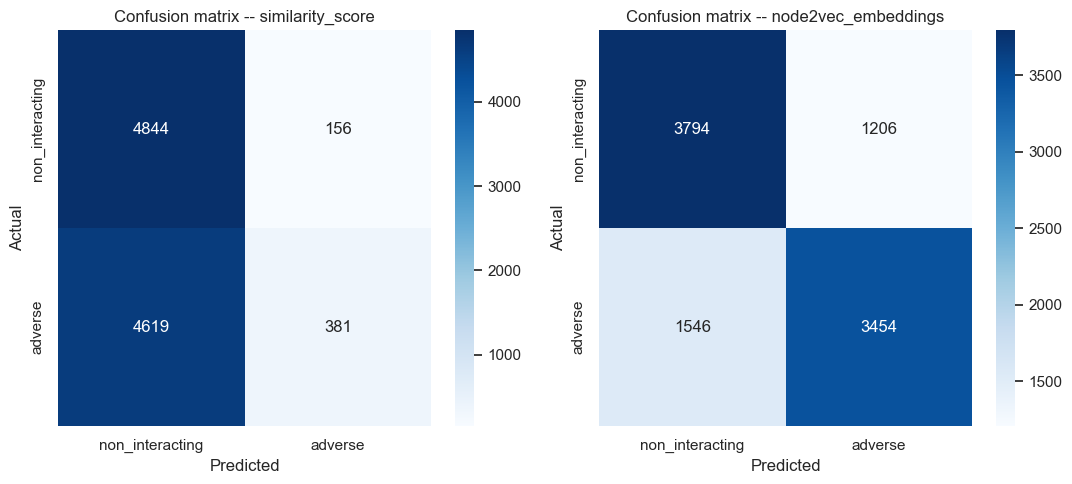

In [10]:
for name in predictions:
    print(f"=== {name} ===")
    print(classification_report(y_test, predictions[name]["y_pred"], target_names=["non_interacting", "adverse"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["non_interacting", "adverse"],
                yticklabels=["non_interacting", "adverse"], ax=ax)
    ax.set_title(f"Confusion matrix -- {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

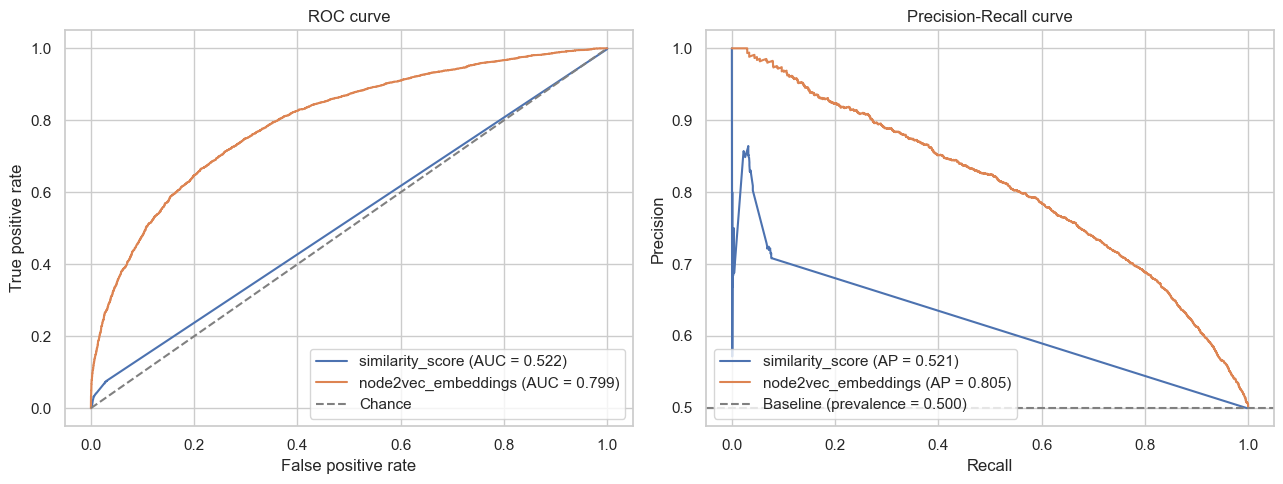

In [11]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for name in predictions:
    y_proba = predictions[name]["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ax_pr.plot(recall, precision, label=f"{name} (AP = {average_precision_score(y_test, y_proba):.3f})")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curve")
ax_roc.legend(loc="lower right")

baseline_precision = y_test.mean()
ax_pr.axhline(baseline_precision, linestyle="--", color="grey", label=f"Baseline (prevalence = {baseline_precision:.3f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curve")
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 7. Which embedding dimensions matter most?

Individual node2vec dimensions aren't directly interpretable the way ATC codes are (each dimension is a learned, abstract coordinate), but ranking Model B's feature importances still shows whether predictive power is concentrated in a few dimensions or spread broadly across the embedding.

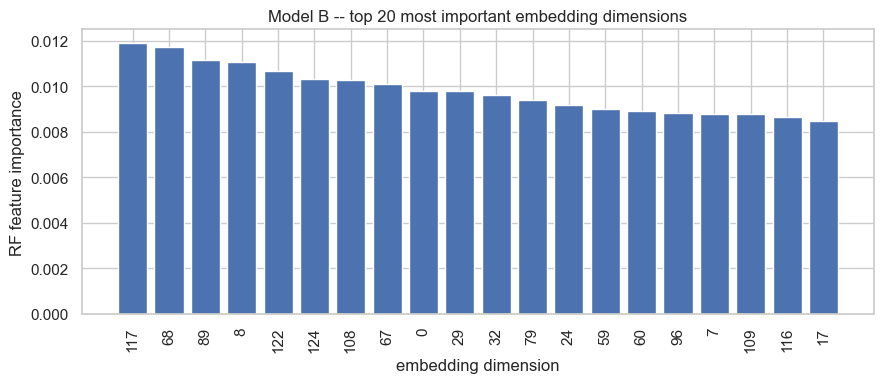

Top 20 dimensions account for 19.6% of total importance (out of 128 dimensions -- uniform would be 15.6%).


In [12]:
importance_df = pd.DataFrame({
    "dimension": np.arange(X_train_b.shape[1]),
    "importance": model_b.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(importance_df["dimension"].head(20).astype(str), importance_df["importance"].head(20))
ax.set_xlabel("embedding dimension")
ax.set_ylabel("RF feature importance")
ax.set_title("Model B -- top 20 most important embedding dimensions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Top 20 dimensions account for {importance_df['importance'].head(20).sum():.1%} of total importance "
      f"(out of {X_train_b.shape[1]} dimensions -- uniform would be {20 / X_train_b.shape[1]:.1%}).")

## 8. Save models

In [13]:
joblib.dump(model_a, MODEL_OUTPUT_DIR / "model_a_similarity_score.joblib")
joblib.dump(model_b, MODEL_OUTPUT_DIR / "model_b_node2vec_embeddings.joblib")
results_df.to_csv(MODEL_OUTPUT_DIR / "results.csv")
print(f"Saved both models and results.csv to {MODEL_OUTPUT_DIR}")

Saved both models and results.csv to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\models\atc_rf_comparison


## Conclusions & recommendations (from the executed run)

### Conclusions

1. **Both models were trained and tested on the exact same 40,000/10,000 rows** (Section 3's synchronized split, 25,000 pairs sampled per class), so the results below are a genuine apples-to-apples comparison:

   | model | dimensionality | accuracy | roc_auc | pr_auc |
   |---|---|---|---|---|
   | similarity_score | 1 | 0.523 | 0.522 | 0.519 |
   | node2vec_embeddings | 128 | **0.717** | **0.800** | **0.806** |

2. **The raw `atc_similarity_score` scalar is barely better than a coin flip** (ROC-AUC 0.522), consistent with `network_generation.ipynb`'s own diagnostic (`auroc_ddi_prediction = 0.538` on the full curated pair list). Its confusion matrix shows why: it predicts "non_interacting" for almost every row (recall on the adverse class is only 0.075), so it can't usefully separate the two classes on its own.
3. **node2vec embeddings recover a large, genuinely useful amount of signal that the raw scalar throws away** (+0.278 ROC-AUC, +0.194 accuracy). This mirrors H3's finding that a single similarity scalar is a lossy compression of the underlying graph, and node2vec's random-walk training recovers multi-hop neighborhood structure the scalar can't represent at all.
4. **This embedding-vs-scalar gap is much larger than H3's structural-similarity gap** (H3: node2vec 0.747 vs. scalar 0.542, a +0.205 ROC-AUC gap). Since H3's raw fingerprint bits (Model C, ROC-AUC 0.827) beat its embeddings, the "raw" ATC representation is a discrete code list, not a fixed-size numeric vector like a fingerprint -- so unlike H3, there's no cheap raw baseline to test here that might beat the embeddings; node2vec is likely close to the practical ceiling for this feature type.
5. **Embedding feature importance is broadly distributed** (top 20 of 128 dimensions = 19.2% of total importance, vs. 15.6% for a uniform split) -- Model B's predictive power isn't concentrated in a handful of dimensions, similar to H3.

### Recommendations

1. **For ATC-based features, prefer the node2vec embedding (`combined_atc_node2vec.parquet`) over the raw similarity score** in any downstream classifier -- the raw scalar is only marginally predictive and would contribute little on its own.
2. Per `node2vec_embedding.ipynb`'s own recommendation, still treat ATC embeddings as a **complementary** feature alongside H1's biological-overlap and H3's structural embeddings, not a standalone predictor, when building the final combined feature table.
3. Consider trying `EMBEDDING_FEATURE_MODE = "average"` or `"abs_diff"` as a follow-up ablation for Model B, since only `"hadamard"` was tested here (matches H3's outstanding recommendation).
4. If a fixed-size raw ATC representation is ever needed for comparison (e.g. multi-hot encoding over the set of all observed ATC codes), it would need dedicated feature engineering rather than reusing `atc_similarity_score` -- there's no existing "Model C" equivalent to H3's fingerprint bits for this feature type yet.